Material for the book Probability and Statistics for Data Science. A free preprint, videos, code, slides and solutions to exercises are available at https://www.ps4ds.net/

Monte Carlo simulations to approximate the pmf of the number of games in a set between Alcaraz and Sinner.\
Topics and relevant videos: [Monte Carlo simulations](https://www.youtube.com/watch?v=vIY_J85hHdw), [explaining the longest match in tennis history](https://youtu.be/EH_HJRo2Oec)

Author: Carlos Fernandez-Granda

In [7]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib
matplotlib.rcParams['text.usetex'] = True
from numpy.random import default_rng

font_size = 15
font_size_legend = 15
font_size_ticks = 15

In [8]:
# Empirical pmf of the number of games in a match
n_games = 6
game = np.zeros(n_games)
game[0] = 1 + 6 + 4 + 6 + 7 + 6 + 3 + 6
game[1] = 6 + 3 + 6 + 7 + 6 + 7 + 7 + 5 + 6 + 3
game[2] = 2 + 6 + 6 + 3 + 3 + 6 + 6 + 4 + 6 + 3
game[3] = 4 + 6 + 6 + 7 + 6 + 4 + 7 + 6 + 7 + 6
game[4] = 6 + 4 + 4 + 6 + 4 + 6 + 4 + 6
game[5] = 6 + 2 + 3 + 6 + 6 + 1 + 6 + 4

max_games = 5 * (6 + 7)
empirical_pmf = np.zeros(max_games + 1)
for ind in range(n_games):
    empirical_pmf[int(game[ind])] += 1. / n_games

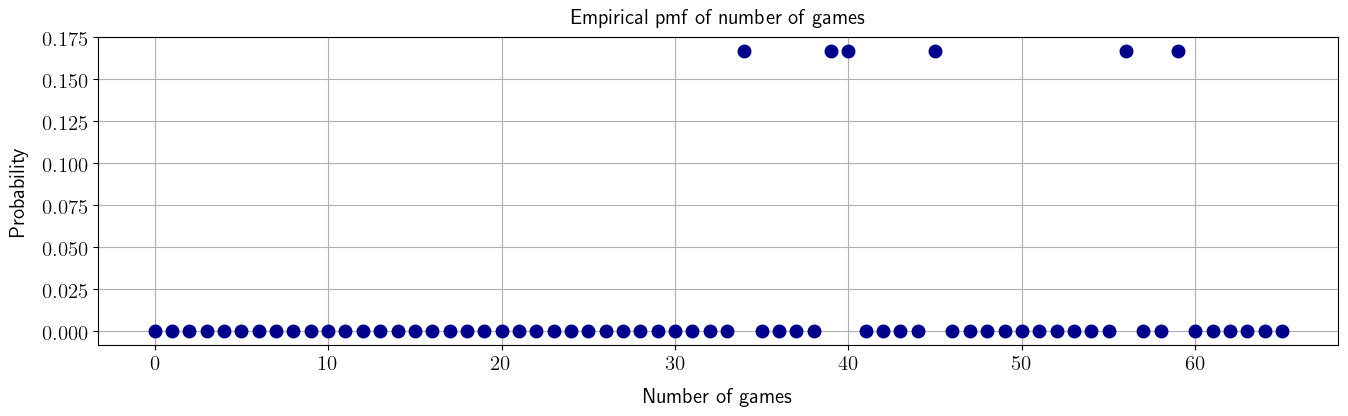

In [9]:
ind_games = range(max_games+1)
plt.figure(figsize=(16,4))
plt.plot(ind_games,empirical_pmf, "o",markersize=8,markerfacecolor='darkblue',markeredgecolor="darkblue",
         markeredgewidth=2)
plt.grid()
plt.xticks(fontsize=font_size_ticks)
plt.xticks(fontsize=font_size_ticks)
plt.yticks(fontsize=font_size_ticks)
plt.ylabel("Probability",fontsize=font_size,labelpad = 10)
plt.xlabel('Number of games',labelpad =10,fontsize=font_size)
plt.title('Empirical pmf of number of games',pad = 10,fontsize=font_size);

In [10]:
# Estimate empirical probability that each player wins a serve point
prob_alcaraz_point = float(76 + 104 + 93 + 117 + 77 + 65) / float(121 + 169 + 157 + 194 + 121 + 89)
print("Empirical probability that Alcaraz wins a serve point",np.around(prob_alcaraz_point,3))
prob_sinner_point = float(101 + 118 + 83 + 116 + 81 + 65) / float(143 + 213 + 135 + 191 + 117 + 112)
print("Empirical probability that Sinner wins a serve point",np.around(prob_sinner_point,3))

Empirical probability that Alcaraz wins a serve point 0.625
Empirical probability that Sinner wins a serve point 0.619


In [11]:
# Code to simulate a single game, assuming that the serve point winning % (win_prob_serve) is known
def simulate_game(win_prob_serve,verbose):
    points_1 = 0
    points_2 = 0
    # The game ends when one player has 4 points or more, and they have at least 2 points more than the other player
    while (points_1 < 4 and points_2 < 4) or np.abs(points_1 - points_2) < 2:
        if rng.random() < win_prob_serve:
            points_1 += 1
        else:
            points_2 += 1
        if verbose:
            print(points_1,"-",points_2)
    if points_1 > points_2:
        # Player who serves wins
        outcome = 1
    else:
        # Player who receives wins
        outcome = 0
    return outcome

In [12]:
def estimate_probability_game(n_games_mc,win_prob_serve):
    won_games = 0
    for ind in range(n_games_mc):
        outcome = simulate_game(win_prob_serve,0)
        if outcome == 1:
            won_games += 1.
    prob_game = won_games / n_games_mc
    return prob_game

In [13]:
# We approximate the probability that each player wins on serve
rng = default_rng(2026)
n_games_mc = int(1e6)
prob_alcaraz_game = estimate_probability_game(n_games_mc,prob_alcaraz_point)
print("Estimated probability that Alcaraz wins a serve game",np.around(prob_alcaraz_game,3))
prob_sinner_game = estimate_probability_game(n_games_mc,prob_sinner_point)
print("Estimated probability that Sinner wins a serve game",np.around(prob_sinner_game,3))

Estimated probability that Alcaraz wins a serve game 0.786
Estimated probability that Sinner wins a serve game 0.774


In [14]:
# Code to simulate a tie break, assuming that the tie break is only until 7 
def simulate_tie_break(who_serves,win_prob_serve_1,win_prob_serve_2,verbose):
    points_1 = 0
    points_2 = 0
    # The tie break ends when one player has 7 points or more, and they have at least 2 points more than the other player
    serve_counter = 0
    first_point = True
    while (points_1 < 7 and points_2 < 7) or np.abs(points_1 - points_2) < 2:
        if verbose:
                print("Player ", who_serves, "serves")
        if who_serves == 1: 
            if rng.random() < win_prob_serve_1:
                points_1 += 1
            else:
                points_2 += 1
            if first_point or serve_counter == 1:
                first_point = False
                serve_counter = 0
                who_serves = 2
            else:
                serve_counter +=1
        else:
            if rng.random() < win_prob_serve_2:
                points_2 += 1
            else:
                points_1 += 1
            if first_point or serve_counter == 1:
                first_point = False
                serve_counter = 0
                who_serves = 1
            else:
                serve_counter +=1
        if verbose:
            print(points_1,"-",points_2)
    if points_1 > points_2:
        outcome = 1
    else:
        outcome = 2
    return outcome

In [15]:
# Test
verbose = 1
simulate_tie_break(2,prob_alcaraz_point,prob_sinner_point,verbose);

Player  2 serves
1 - 0
Player  1 serves
2 - 0
Player  1 serves
3 - 0
Player  2 serves
3 - 1
Player  2 serves
3 - 2
Player  1 serves
4 - 2
Player  1 serves
5 - 2
Player  2 serves
5 - 3
Player  2 serves
6 - 3
Player  1 serves
7 - 3


In [16]:
def estimate_probability_tie_break(n_games_mc,win_prob_serve_1,win_prob_serve_2):
    won_games = 0
    for ind in range(n_games_mc):
        outcome = simulate_tie_break(1,win_prob_serve_1,win_prob_serve_2,0)
        if outcome == 1:
            won_games += 1.
    prob_game = won_games / n_games_mc
    return prob_game

In [17]:
# We approximate the probability that each player wins a tie break if they serve first
rng = default_rng(2026)
n_games_mc = int(1e6)
prob_alcaraz_tie_break = estimate_probability_tie_break(n_games_mc,prob_alcaraz_point,prob_sinner_point)
print("Estimated probability that Alcaraz wins a tie break if he serves first",np.around(prob_alcaraz_tie_break,4))
prob_sinner_tie_break = estimate_probability_tie_break(n_games_mc,prob_sinner_point,prob_alcaraz_point)
print("Estimated probability that Sinner wins a tie break if he serves first",np.around(prob_sinner_tie_break,4))

Estimated probability that Alcaraz wins a tie break if he serves first 0.5096
Estimated probability that Sinner wins a tie break if he serves first 0.4901


In [18]:
# Code to simulate a single set, 1 is Alcaraz and 2 is Sinner
def simulate_set(who_serves,verbose):
    games_1 = 0
    games_2 = 0
    # The set ends when one player has 6 games or more, and they have at least 2 games more than the other player
    tie_break = False
    while (games_1 < 6 and games_2 < 6) or np.abs(games_1 - games_2) < 2:
        if verbose:
            print("Player ", who_serves, "serves")
        if who_serves == 1: 
            if rng.random() < prob_alcaraz_game:
                games_1 += 1
            else:
                games_2 += 1
            who_serves = 2
        else:
            if rng.random() < prob_sinner_game:
                games_2 += 1
            else:
                games_1 += 1
            who_serves = 1
        if verbose:
            print(games_1,"-",games_2)
        # At 6 - 6 we reach a tie break
        if (games_1 == 6) and (games_2 == 6):
            tie_break = True
            break
    if tie_break:
        if verbose:
            print("Player ", who_serves, "serves")
        if who_serves == 1: 
            if rng.random() < prob_alcaraz_tie_break:
                games_1 += 1
            else:
                games_2 += 1
            who_serves = 2
        else:
            if rng.random() < prob_sinner_tie_break:
                games_2 += 1
            else:
                games_1 += 1
            who_serves = 1
        if verbose:
            print(games_1,"-",games_2)
    total_games = games_1 + games_2
    if games_1 > games_2:
        who_wins = 1
    else:
        who_wins = 2
    return [total_games, who_wins, who_serves]

In [19]:
# Code to simulate a match
def simulate_match(verbose):
    sets_1 = 0
    sets_2 = 0
    # Each player starts serving with probability 1/2
    who_serves = 1
    if rng.random() < 0.5:
        who_serves = 2
    # The match ends when one player has 3 sets
    total_games_match = 0
    while (sets_1 < 3 and sets_2 < 3):
        [total_games_set, who_wins, who_serves] = simulate_set(who_serves,verbose)
        total_games_match += total_games_set
        if who_wins == 1:
            sets_1 += 1
        else:
            sets_2 += 1
        if verbose:
            print("Sets:",sets_1,"-",sets_2)
            print("Total games set",total_games_set)
            print("Total games match",total_games_match)
            print(who_serves,"serves")
    return total_games_match

In [20]:
# Test
rng = default_rng(2026)
total_games = simulate_match(1)

Player  2 serves
0 - 1
Player  1 serves
1 - 1
Player  2 serves
1 - 2
Player  1 serves
2 - 2
Player  2 serves
3 - 2
Player  1 serves
3 - 3
Player  2 serves
3 - 4
Player  1 serves
4 - 4
Player  2 serves
4 - 5
Player  1 serves
4 - 6
Sets: 0 - 1
Total games set 10
Total games match 10
2 serves
Player  2 serves
1 - 0
Player  1 serves
2 - 0
Player  2 serves
2 - 1
Player  1 serves
3 - 1
Player  2 serves
4 - 1
Player  1 serves
5 - 1
Player  2 serves
5 - 2
Player  1 serves
6 - 2
Sets: 1 - 1
Total games set 8
Total games match 18
2 serves
Player  2 serves
0 - 1
Player  1 serves
1 - 1
Player  2 serves
1 - 2
Player  1 serves
2 - 2
Player  2 serves
2 - 3
Player  1 serves
3 - 3
Player  2 serves
3 - 4
Player  1 serves
4 - 4
Player  2 serves
4 - 5
Player  1 serves
5 - 5
Player  2 serves
5 - 6
Player  1 serves
6 - 6
Player  2 serves
7 - 6
Sets: 2 - 1
Total games set 13
Total games match 31
1 serves
Player  1 serves
0 - 1
Player  2 serves
0 - 2
Player  1 serves
1 - 2
Player  2 serves
2 - 2
Player  1 ser

In [21]:
# We approximate the pmf of the number of games
rng = default_rng(2026)
n_games_mc = int(1e6)

pmf_mc = np.zeros(max_games + 1)
for ind in range(n_games_mc):
    total_games_match = simulate_match(0)
    pmf_mc[total_games_match] += 1./n_games_mc

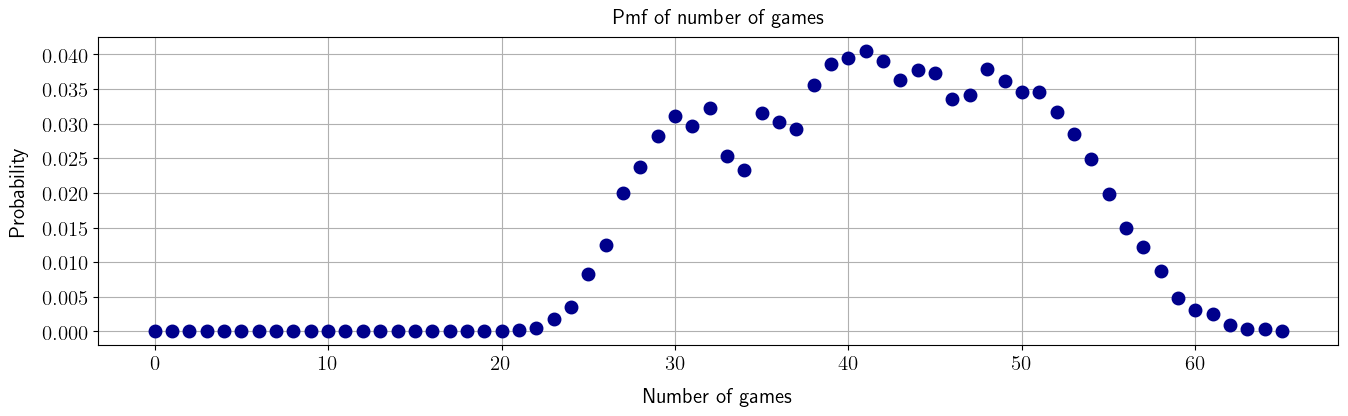

In [22]:
plt.figure(figsize=(16,4))
plt.plot(ind_games,pmf_mc, "o",markersize=8,markerfacecolor='darkblue',markeredgecolor="darkblue",
         markeredgewidth=2)
plt.grid()
plt.xticks(fontsize=font_size_ticks)
plt.xticks(fontsize=font_size_ticks)
plt.yticks(fontsize=font_size_ticks)
plt.ylabel("Probability",fontsize=font_size,labelpad = 10)
plt.xlabel('Number of games',labelpad =10,fontsize=font_size)
plt.title('Pmf of number of games',pad = 10,fontsize=font_size);

In [23]:
# We verify the result changing the random seed
rng = default_rng(2027)
n_matches_mc = int(1e6)

pmf_mc = np.zeros(max_games + 1)
for ind in range(n_matches_mc):
    total_games_match = simulate_match(0)
    pmf_mc[total_games_match] += 1./n_matches_mc

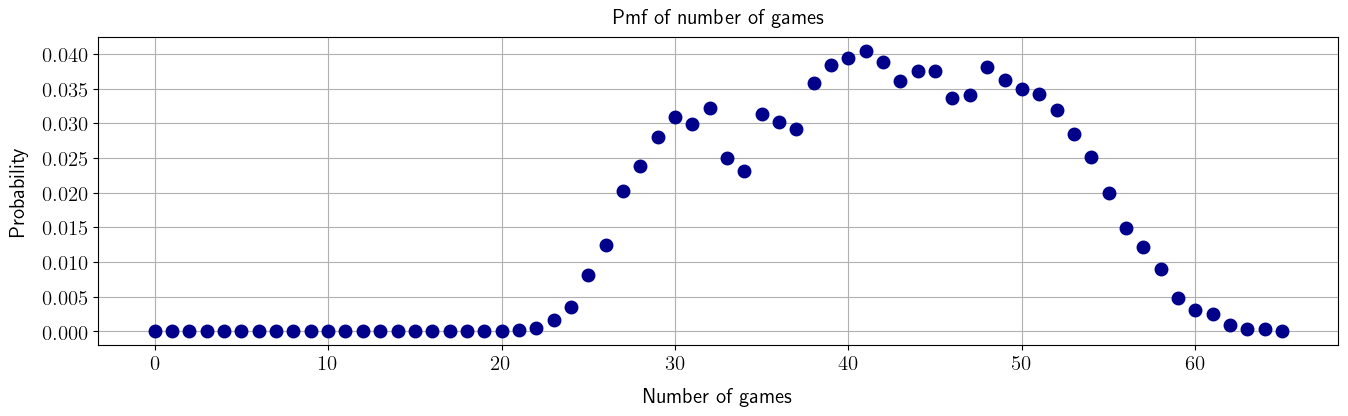

In [24]:
plt.figure(figsize=(16,4))
plt.plot(ind_games,pmf_mc, "o",markersize=8,markerfacecolor='darkblue',markeredgecolor="darkblue",
         markeredgewidth=2)
plt.grid()
plt.xticks(fontsize=font_size_ticks)
plt.xticks(fontsize=font_size_ticks)
plt.yticks(fontsize=font_size_ticks)
plt.ylabel("Probability",fontsize=font_size,labelpad = 10)
plt.xlabel('Number of games',labelpad =10,fontsize=font_size)
plt.title('Pmf of number of games',pad = 10,fontsize=font_size);